# Experiment 5 — K-Nearest Neighbors

**Dataset:** MNIST / Digit Recognizer (Kaggle)

**Objective:** Identify handwritten digits using KNN and Euclidean distance.

> Kaggle setup: Add the dataset listed above to the notebook. The code automatically searches `/kaggle/input` for the required files/folders where possible.

In [1]:

import os, glob, warnings
warnings.filterwarnings("ignore")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Load MNIST

In [3]:
# Prefer the classic Kaggle Digit Recognizer train.csv.
paths = glob.glob("/kaggle/input/**/train.csv", recursive=True)
if not paths:
    paths = glob.glob("/kaggle/input/**/*.csv", recursive=True)
    paths = [p for p in paths if "mnist" in p.lower() or "digit" in p.lower()]
if not paths:
    raise FileNotFoundError("Add Kaggle Digit Recognizer / MNIST dataset.")
path = paths[0]
df = pd.read_csv(path)
print("Loaded:", path, "shape:", df.shape)
display(df.head())

Loaded: /kaggle/input/competitions/digit-recognizer/train.csv shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Prepare handwritten digits

In [4]:
target = "label" if "label" in df.columns else df.columns[0]
X = df.drop(columns=[target])
y = df[target]

# Use a manageable, stratified subset for KNN.
MAX_SAMPLES = min(12000, len(df))
X_sub, _, y_sub, _ = train_test_split(
    X, y, train_size=MAX_SAMPLES, random_state=42, stratify=y
)

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.20, random_state=42, stratify=y_sub
)

# Scale pixel values. With KNN, distance is the key idea.
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

model = KNeighborsClassifier(n_neighbors=3, metric="euclidean", n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test,y_pred)*100,2), "%")
print(classification_report(y_test,y_pred))

Accuracy: 94.75 %
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       236
           1       0.92      0.99      0.95       268
           2       0.99      0.95      0.97       239
           3       0.93      0.95      0.94       249
           4       0.93      0.93      0.93       233
           5       0.95      0.93      0.94       217
           6       0.99      0.97      0.98       236
           7       0.93      0.95      0.94       251
           8       1.00      0.88      0.93       232
           9       0.92      0.92      0.92       239

    accuracy                           0.95      2400
   macro avg       0.95      0.95      0.95      2400
weighted avg       0.95      0.95      0.95      2400



## 3. Confusion matrix

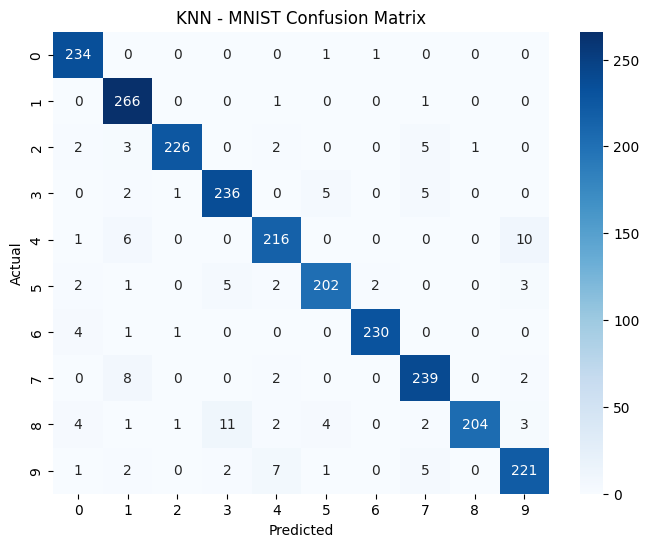

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - MNIST Confusion Matrix")
plt.show()

## 4. Visualize predictions

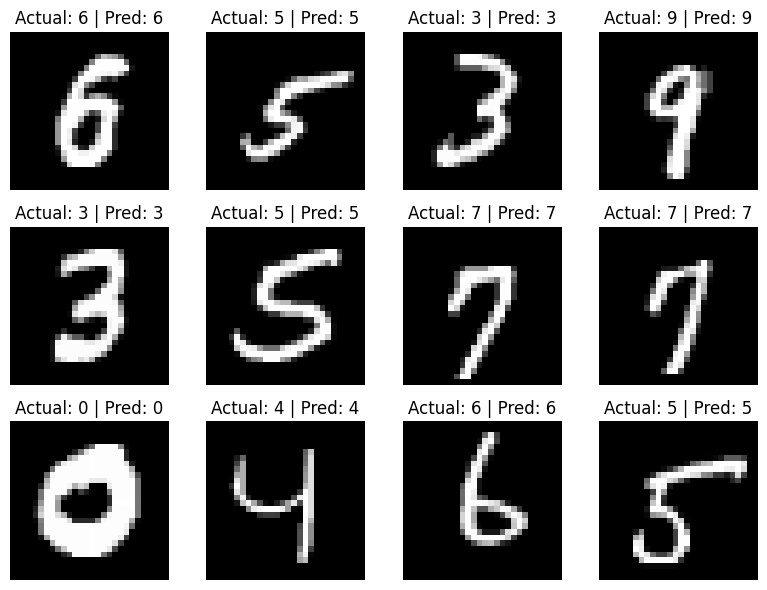

In [6]:
images = X_test.iloc[:12].values.reshape(-1, 28, 28)
labels = np.array(y_test.iloc[:12])
preds = np.array(y_pred[:12])

fig, axes = plt.subplots(3,4, figsize=(8,6))
for ax, img, true, pred in zip(axes.ravel(), images, labels, preds):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Actual: {true} | Pred: {pred}")
    ax.axis("off")
plt.tight_layout()
plt.show()